# Task 5: Personal Loan Acceptance Prediction

## Introduction
The Bank Marketing Dataset is a widely used dataset in the banking and finance domain. It contains information about customer demographics, account details, and previous marketing campaign interactions from a Portuguese banking institution.

The goal is to predict whether a customer will accept a **personal loan** (or term deposit) offer based on various features such as age, job, marital status, education, account balance, and campaign-related data.

## Objective
Develop a machine learning model to predict loan acceptance, perform exploratory data analysis (EDA), compare classification models, and extract actionable business insights to help the bank improve its targeted marketing strategy.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [60]:
df = pd.read_excel("bank.xlsx", sheet_name="Data")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (5000, 14)

Columns: ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [63]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

print("\nTarget Distribution:")
print(df["Personal Loan"].value_counts())

print(f"\nAcceptance Rate: {(df['Personal Loan'] == 1).mean() * 100:.2f}%")

df.describe()

Data Types:
 ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

Missing Values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Target Distribution:
Personal Loan
0    4520
1     480
Name: count, dtype: int64

Acceptance Rate: 9.60%


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937913,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747666,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

['Description', 'Data']

In [64]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

if "Personal Loan" in cat_cols:
    cat_cols.remove("Personal Loan")

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


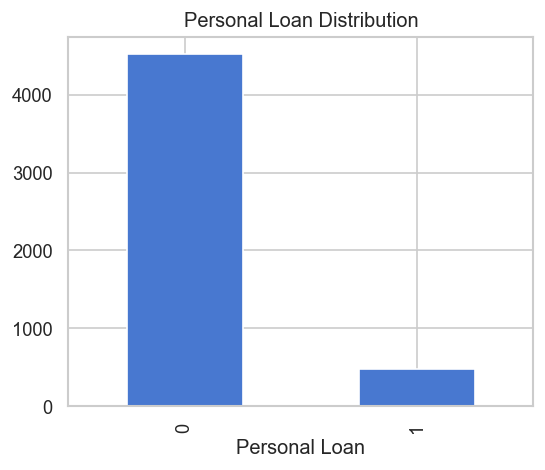

In [65]:
plt.figure(figsize=(5,4))

df["Personal Loan"].value_counts().plot(kind="bar")

plt.title("Personal Loan Distribution")
plt.show()

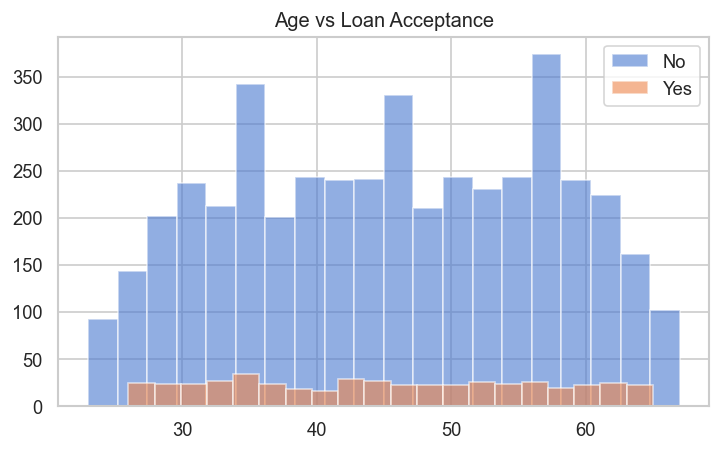

In [66]:
plt.figure(figsize=(7,4))

df[df["Personal Loan"] == 0]["Age"].hist(alpha=0.6, bins=20, label="No")
df[df["Personal Loan"] == 1]["Age"].hist(alpha=0.6, bins=20, label="Yes")

plt.legend()
plt.title("Age vs Loan Acceptance")
plt.show()

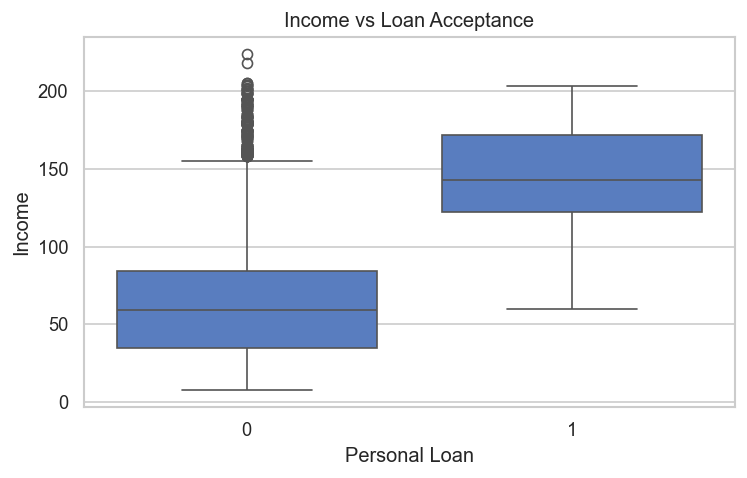

In [67]:
plt.figure(figsize=(7,4))

sns.boxplot(x="Personal Loan", y="Income", data=df)

plt.title("Income vs Loan Acceptance")
plt.show()

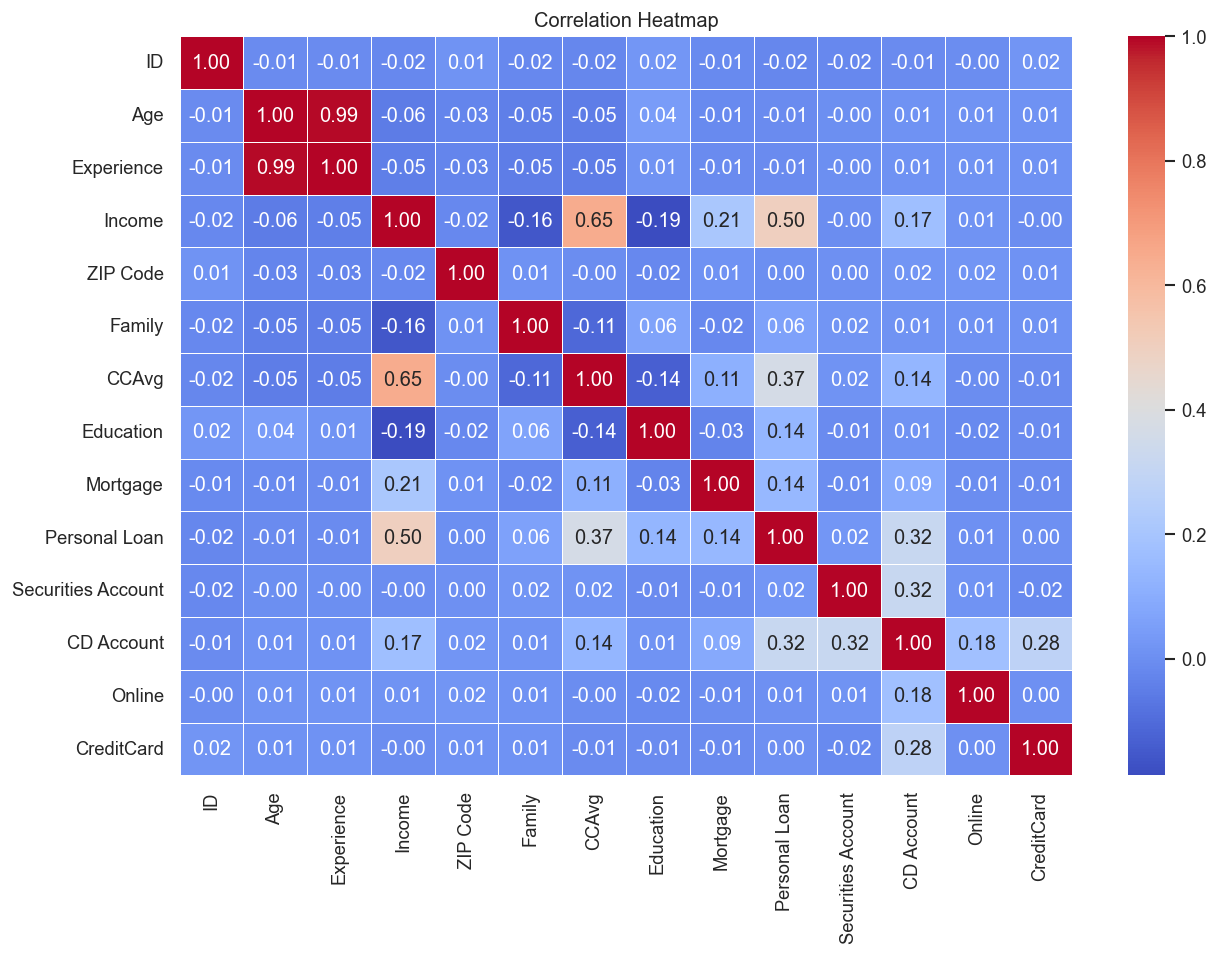

In [70]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [71]:
X = df.drop("Personal Loan", axis=1)
y = df["Personal Loan"]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# scale features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.954


In [75]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.984


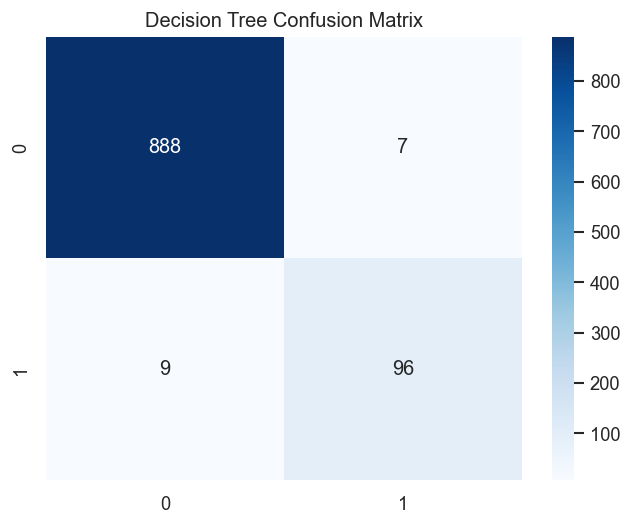

In [76]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [77]:
print("Decision Tree Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       895
           1       0.93      0.91      0.92       105

    accuracy                           0.98      1000
   macro avg       0.96      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



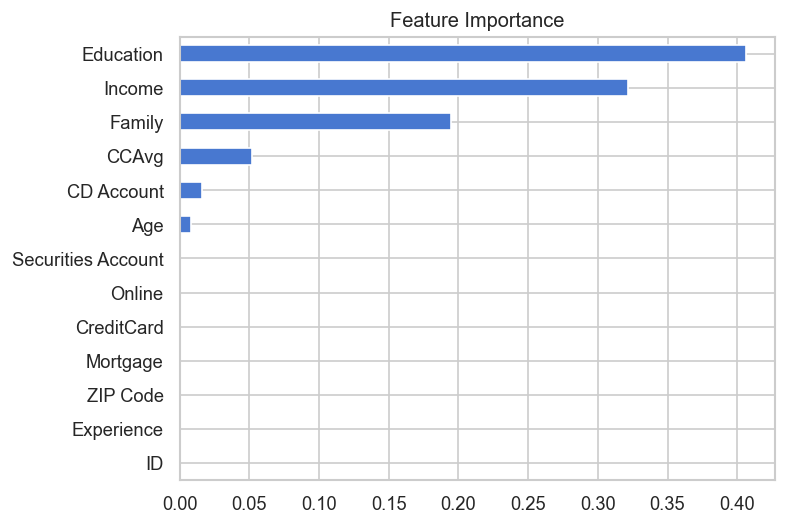

In [78]:
importance = pd.Series(dt.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.show()

# Conclusion

In this project, we analyzed the Bank Personal Loan dataset to understand the factors influencing customer acceptance of personal loan offers. After performing data cleaning, exploratory data analysis, and feature encoding, we built and evaluated classification models to predict loan acceptance behavior.

The exploratory analysis showed that only a small proportion of customers accepted the loan offer, indicating a significant class imbalance. Customer attributes such as income, credit card spending, education level, and account-related features showed noticeable influence on loan acceptance patterns.

Two machine learning models were implemented: Logistic Regression and Decision Tree Classifier. Both models performed well, with Logistic Regression achieving high accuracy after feature scaling, highlighting the importance of proper preprocessing for model convergence and stability. The Decision Tree model also provided interpretability through feature importance analysis.

Overall, the results indicate that income-related features and financial behavior are strong predictors of loan acceptance. These insights can help the bank better target potential customers, improve marketing efficiency, and increase conversion rates.

This project demonstrates the application of data preprocessing, visualization, and supervised learning techniques to solve a real-world business problem in the banking sector.
